In [1]:
# import
import pickle as pkl
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
import matplotlib.patches as mpatches
from sklearn.model_selection import StratifiedGroupKFold
import os

# pandas 버전이 맞지않아서 우회
sys.modules['pandas.indexes'] = pd.core.indexes

In [2]:
# Load pkl file
with open('/home/geonyoung_lee/fab_scope/data/LSWMD.pkl', 'rb') as f:
    data : pd.DataFrame = pkl.load(f, encoding='latin1')

In [3]:
"""
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
"""
print(data.info())



<class 'pandas.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB
None


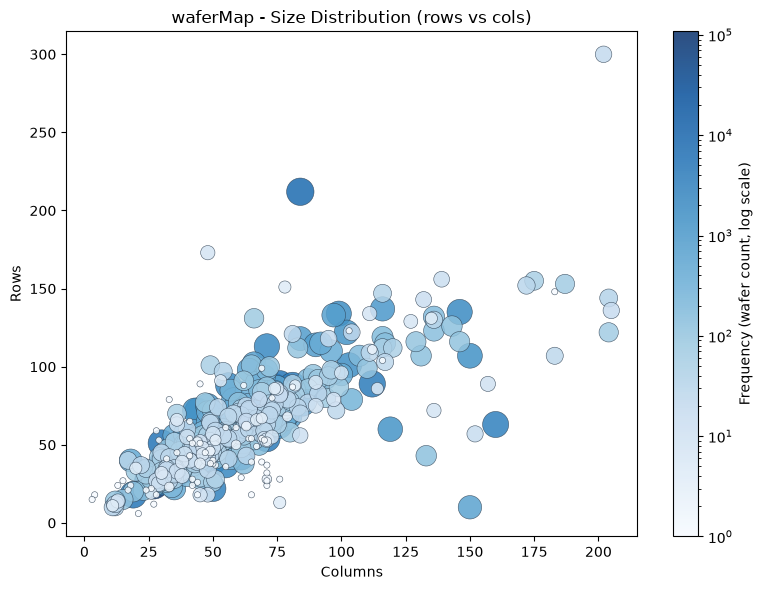

[Summary] waferMap 크기(shape) 분포
- 전체 웨이퍼 수: 811,457개
- Rows: min=6, max=300, mean=45.1, median=36
- Cols: min=3, max=205, mean=43.1, median=35
- 서로 다른 (rows, cols) 조합 개수: 632가지
- 가장 흔한 크기: (32, 29) (108,687개, 13.4%)


In [4]:
"""
waferMap : 웨이퍼의 실제 칩 상태를 나타내는 2D 행렬

{0, 1, 2}
0 : die가 아닌 공간
1 : 정상 die
2 : 비정상 die
"""
# 전체 데이터(811,457개)에 대해 waferMap 크기(행렬 shape) 분포 확인
wafer_shapes = data['waferMap'].apply(lambda wm: wm.shape)
wafer_rows = wafer_shapes.apply(lambda s: s[0])
wafer_cols = wafer_shapes.apply(lambda s: s[1])

# (rows, cols) 조합별 빈도 -> 버블 크기 + 색상(log scale)으로 인코딩
# (811,457개 원본 점을 그대로 찍으면 과도한 중첩 발생, 선형 크기만으로는 빈도 편차가 안 보임)
shape_counts = wafer_shapes.value_counts()
shape_rows = [s[0] for s in shape_counts.index]
shape_cols = [s[1] for s in shape_counts.index]
shape_freq = shape_counts.values

log_freq = np.log10(shape_freq)
size_norm = (log_freq - log_freq.min()) / (log_freq.max() - log_freq.min())
marker_sizes = 20 + 480 * size_norm
log_norm = mcolors.LogNorm(vmin=shape_freq.min(), vmax=shape_freq.max())

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(shape_cols, shape_rows, s=marker_sizes, c=shape_freq, cmap='Blues',
                 norm=log_norm, alpha=0.85, edgecolor='#2c3e50', linewidth=0.4)
ax.set_title('waferMap - Size Distribution (rows vs cols)')
ax.set_xlabel('Columns')
ax.set_ylabel('Rows')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Frequency (wafer count, log scale)')

plt.tight_layout()
plt.show()

most_common_shape = shape_counts.index[0]
most_common_count = shape_counts.iloc[0]

print('=' * 55)
print('[Summary] waferMap 크기(shape) 분포')
print(f'- 전체 웨이퍼 수: {len(wafer_shapes):,}개')
print(f'- Rows: min={wafer_rows.min()}, max={wafer_rows.max()}, '
      f'mean={wafer_rows.mean():.1f}, median={wafer_rows.median():.0f}')
print(f'- Cols: min={wafer_cols.min()}, max={wafer_cols.max()}, '
      f'mean={wafer_cols.mean():.1f}, median={wafer_cols.median():.0f}')
print(f'- 서로 다른 (rows, cols) 조합 개수: {wafer_shapes.nunique():,}가지')
print(f'- 가장 흔한 크기: {most_common_shape} '
      f'({most_common_count:,}개, {most_common_count / len(wafer_shapes) * 100:.1f}%)')
print('=' * 55)

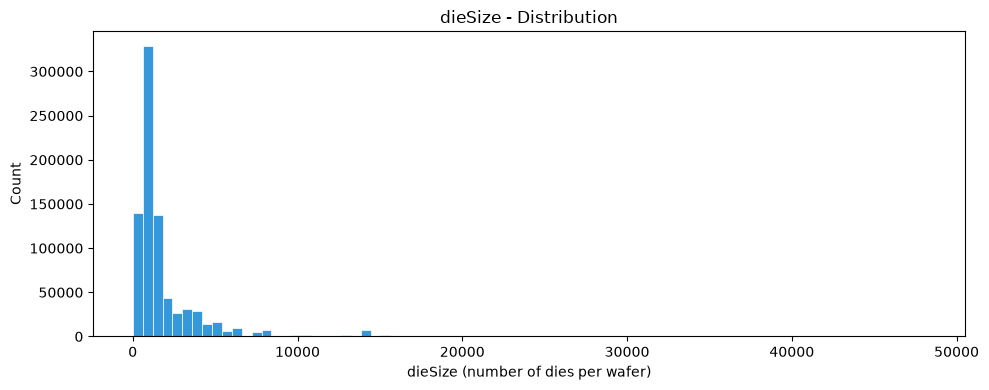

[Summary] dieSize 분포
- 전체 웨이퍼 수: 811,457개
- min=3, max=48099, mean=1841.0, median=953
- 표준편차: 2255.0
- 25%~75% 구간: 710 ~ 1902


In [5]:
"""
dieSize : 웨이퍼 상에 배치된 실제 칩들의 총 개수

3 ~ 48099
"""
plt.figure(figsize=(10, 4))
plt.hist(data['dieSize'], bins=80, color='#3498db', edgecolor='white', linewidth=0.5)
plt.title('dieSize - Distribution')
plt.xlabel('dieSize (number of dies per wafer)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

die_size = data['dieSize']
print('=' * 55)
print('[Summary] dieSize 분포')
print(f'- 전체 웨이퍼 수: {len(die_size):,}개')
print(f'- min={die_size.min():.0f}, max={die_size.max():.0f}, '
      f'mean={die_size.mean():.1f}, median={die_size.median():.0f}')
print(f'- 표준편차: {die_size.std():.1f}')
print(f'- 25%~75% 구간: {die_size.quantile(0.25):.0f} ~ {die_size.quantile(0.75):.0f}')
print('=' * 55)

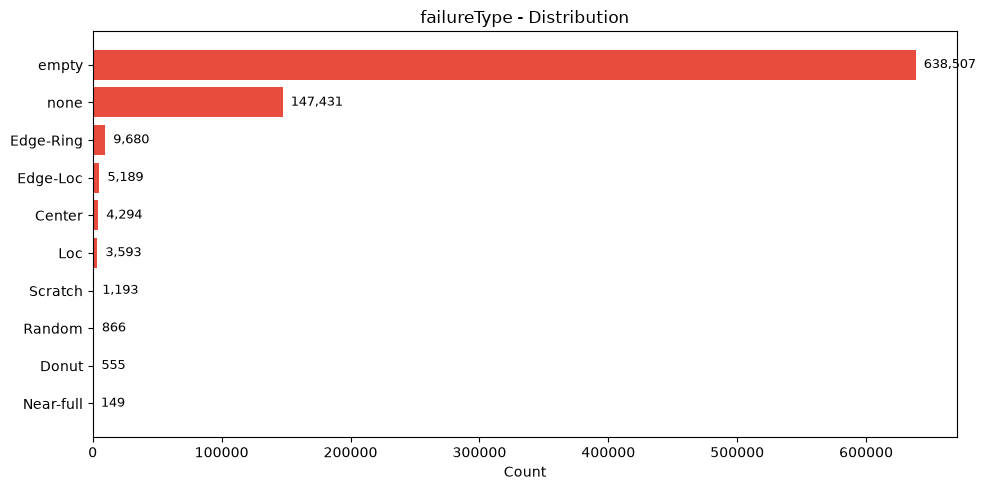

[Summary] failureType 분포
- empty: 638,507개 (78.7%)
- none: 147,431개 (18.2%)
- Edge-Ring: 9,680개 (1.2%)
- Edge-Loc: 5,189개 (0.6%)
- Center: 4,294개 (0.5%)
- Loc: 3,593개 (0.4%)
- Scratch: 1,193개 (0.1%)
- Random: 866개 (0.1%)
- Donut: 555개 (0.1%)
- Near-full: 149개 (0.0%)
- 실제 불량(defect) 유형 비율 합계: 3.14%
- 가장 흔한 불량 유형: Edge-Ring (9,680개)
- 가장 드문 불량 유형: Near-full (149개)
- 불량 유형 간 불균형 비율(최다/최소): 65.0배


In [6]:
"""
failureType : 웨이퍼의 실패 유형

{'none', 'empty', 'Near-full', 'Edge-Loc', 'Donut', 'Loc', 'Random', 'Center', 'Edge-Ring', 'Scratch'}

'none' : 정상 웨이퍼
'empty' : 데이터가 비어있음
'Near-full' : 웨이퍼 거의 전체가 불량인 형태
'Edge-Loc' : 웨이퍼 가장자리 특정 영역에 쏠린 불량
'Donut' : 도넛 모양의 링 패턴 불량
'Loc' : 특정 부분에 국소적으로 몰려 있는 불량
'Random' : 무작위로 흩어져 있는 불량
'Center' : 중앙에 불량이 집중된 형태
'Edge-Ring' : 가장자리를 따라 둥글게 나타나는 불량
'Scratch' : 긁힌 선 모양의 불량 패턴
"""
failure_counts = data['failureType'].apply(
    lambda x: x.item() if len(x) > 0 else 'empty'
).value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(failure_counts.index[::-1], failure_counts.values[::-1], color='#e74c3c')
plt.title('failureType - Distribution')
plt.xlabel('Count')
for bar, count in zip(bars, failure_counts.values[::-1]):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'  {count:,}',
             va='center', fontsize=9)
plt.tight_layout()
plt.show()

total = failure_counts.sum()
defect_counts = failure_counts.drop(index=[l for l in ['none', 'empty'] if l in failure_counts.index])

print('=' * 55)
print('[Summary] failureType 분포')
for label, count in failure_counts.items():
    print(f'- {label}: {count:,}개 ({count / total * 100:.1f}%)')
print(f'- 실제 불량(defect) 유형 비율 합계: {defect_counts.sum() / total * 100:.2f}%')
print(f'- 가장 흔한 불량 유형: {defect_counts.idxmax()} ({defect_counts.max():,}개)')
print(f'- 가장 드문 불량 유형: {defect_counts.idxmin()} ({defect_counts.min():,}개)')
print(f'- 불량 유형 간 불균형 비율(최다/최소): {defect_counts.max() / defect_counts.min():.1f}배')
print('=' * 55)

In [7]:
"""
waferMap - 원본 vs Nearest Neighbor 리사이즈(52x52, 64x64, 96x96) 비교 시각화

바로 위 셀에서 추출한 sampled_indices의 동일한 wafer를 원본과 각 리사이즈 크기로 나란히 표시
PIL(Image.resize + Image.NEAREST)로 리사이즈 (카테고리 값 {0,1,2}를 보존하기 위해 nearest neighbor 사용)

failureType별로 plot_resolution_comparison('<failureType>')을 호출하면
행=5개 샘플, 열=[Original, 52x52, 64x64, 96x96]인 비교 그리드 1개가 그려진다
"""

np.random.seed(42)

failure_order = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']
failure_type_str = data['failureType'].apply(lambda x: x.item() if len(x) > 0 else 'empty')
pixel_colors = ['#000000', '#0000FF', '#FF0000']
cmap = mcolors.ListedColormap(pixel_colors)
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

n_samples = 30
sampled_indices = {}
for ftype in failure_order:
    idx_pool = data.index[failure_type_str == ftype].to_numpy()
    sampled_indices[ftype] = np.random.choice(idx_pool, size=n_samples, replace=False)

def resize_nearest(wafer_map: np.ndarray, size: tuple) -> np.ndarray:
    img = Image.fromarray(wafer_map.astype(np.uint8), mode='L')
    resized = img.resize(size, resample=Image.NEAREST)
    return np.array(resized)


target_sizes = [('Original', None), ('64x64', (64, 64))]


def plot_resolution_comparison(ftype: str):
    fig, axes = plt.subplots(n_samples, len(target_sizes),
                              figsize=(2.2 * len(target_sizes), 2.4 * n_samples))

    for row, idx in enumerate(sampled_indices[ftype]):
        wafer = data.loc[idx, 'waferMap']
        for col, (size_label, size) in enumerate(target_sizes):
            ax = axes[row, col]
            img = wafer if size is None else resize_nearest(wafer, size)
            ax.imshow(img, cmap=cmap, norm=norm, interpolation='nearest')
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel(f'{img.shape[0]}x{img.shape[1]}', fontsize=8)
            if row == 0:
                ax.set_title(size_label, fontsize=12)
            if col == 0:
                ax.set_ylabel(f'sample {row + 1}', fontsize=10, rotation=0, ha='right', va='center')

    legend_patches = [
        mpatches.Patch(color=pixel_colors[0], label='Non-die'),
        mpatches.Patch(color=pixel_colors[1], label='Normal die'),
        mpatches.Patch(color=pixel_colors[2], label='Defective die'),
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3, frameon=False,
               fontsize=11, bbox_to_anchor=(0.5, -0.01))

    label = 'none (baseline)' if ftype == 'none' else ftype
    fig.suptitle(f'waferMap comparison - failureType: {label}', fontsize=15, y=1.02)
    plt.tight_layout(rect=[0, 0.02, 1, 0.99])
    plt.show()

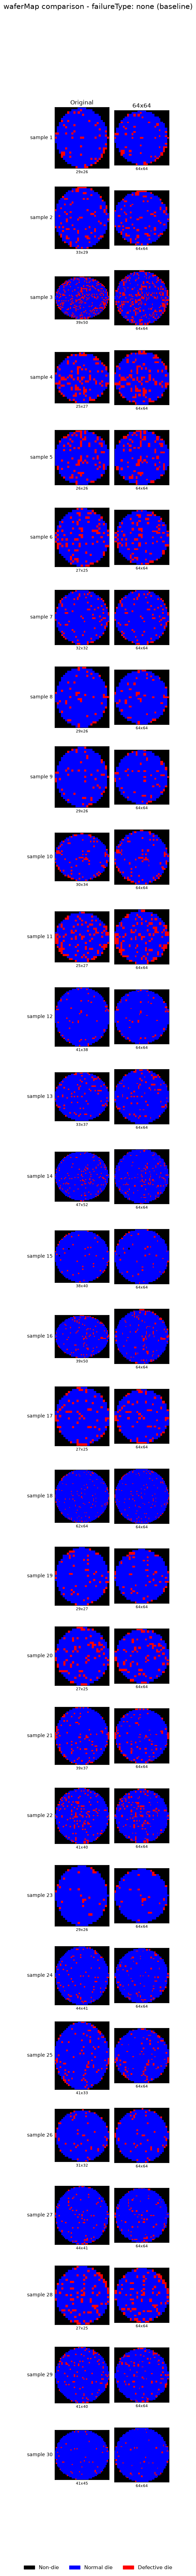

In [8]:
plot_resolution_comparison('none')

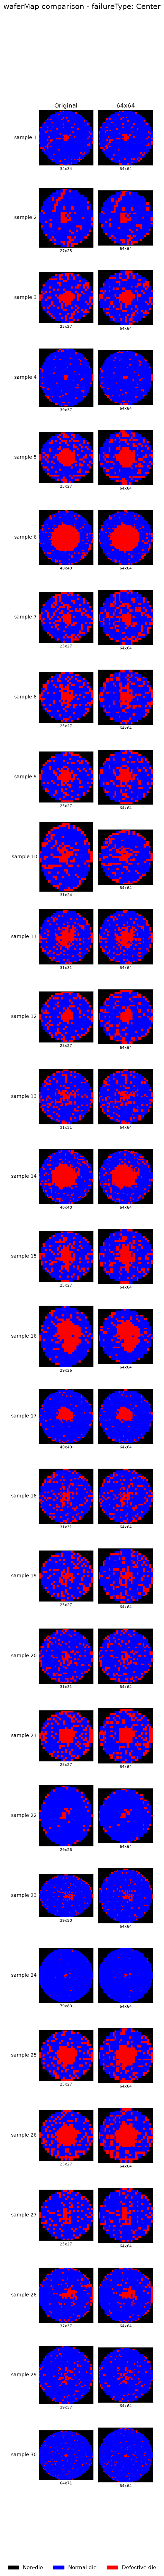

In [9]:
plot_resolution_comparison('Center')

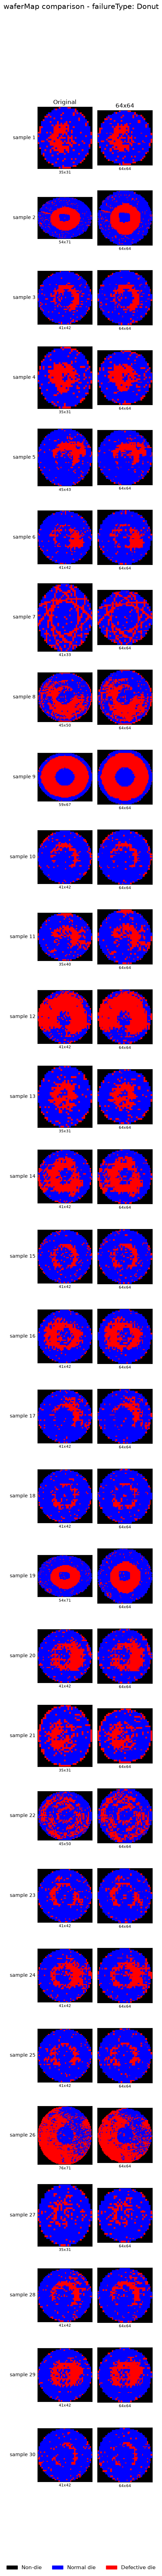

In [10]:
plot_resolution_comparison('Donut')

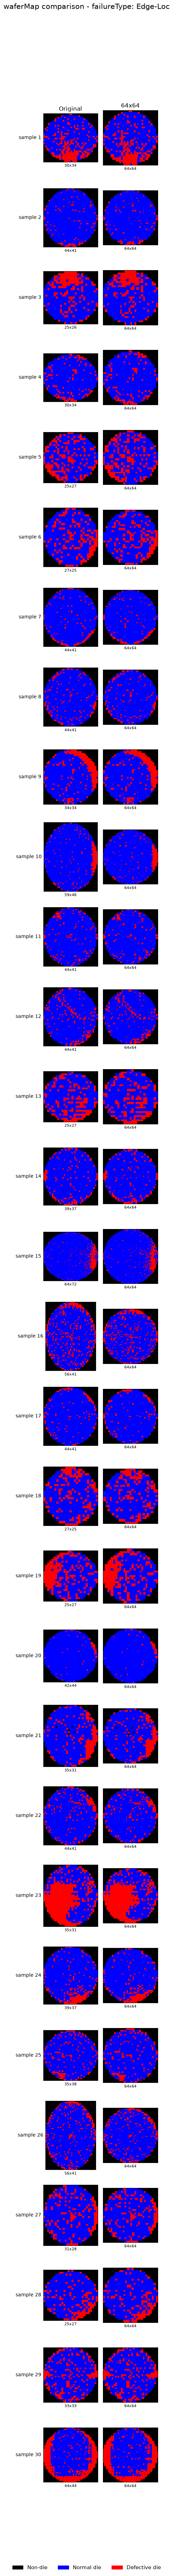

In [11]:
plot_resolution_comparison('Edge-Loc')

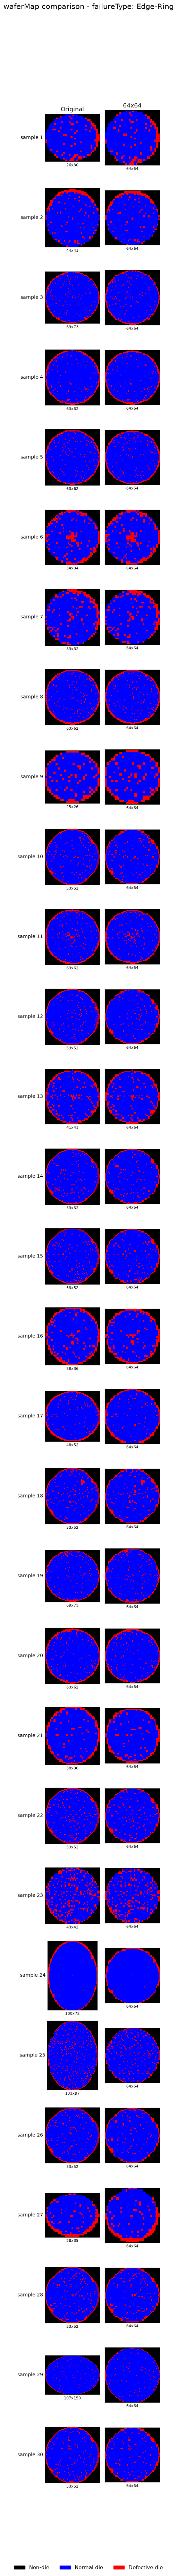

In [12]:
plot_resolution_comparison('Edge-Ring')

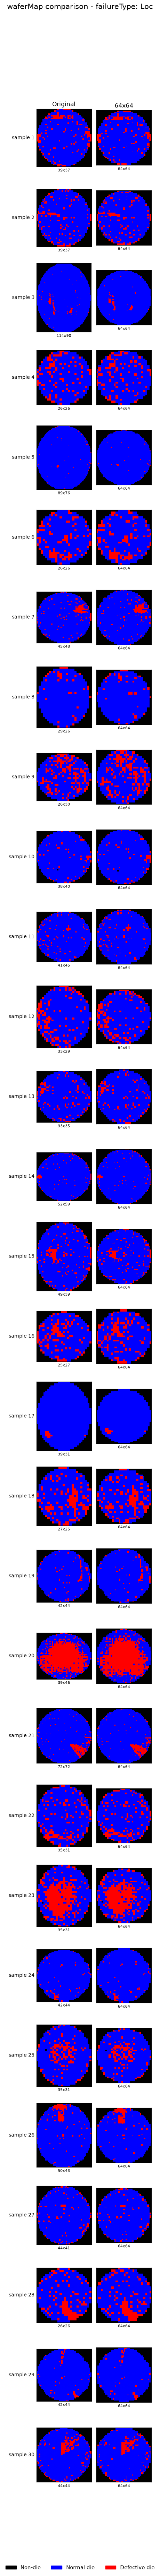

In [13]:
plot_resolution_comparison('Loc')

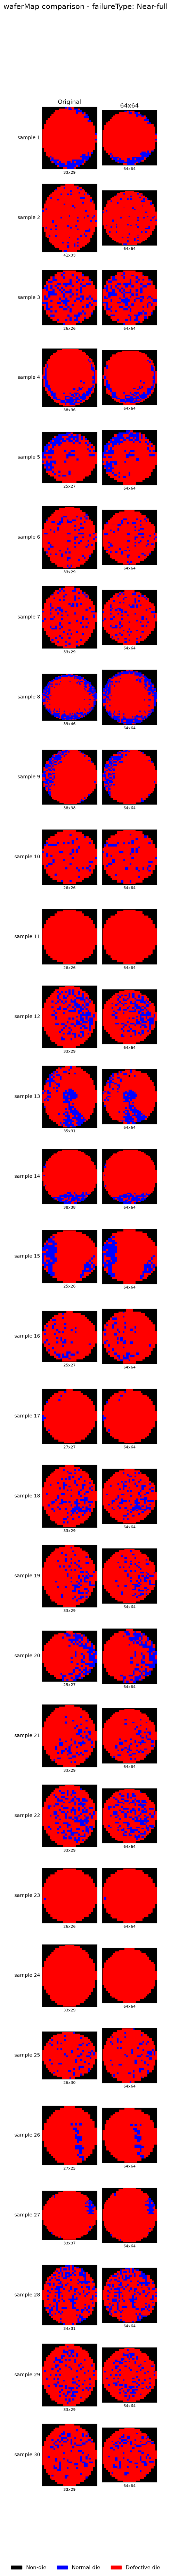

In [14]:
plot_resolution_comparison('Near-full')

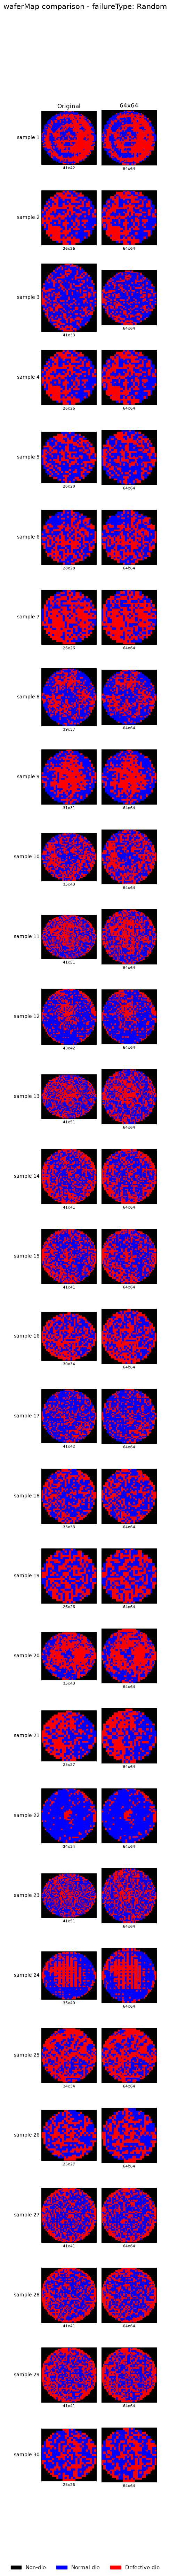

In [15]:
plot_resolution_comparison('Random')

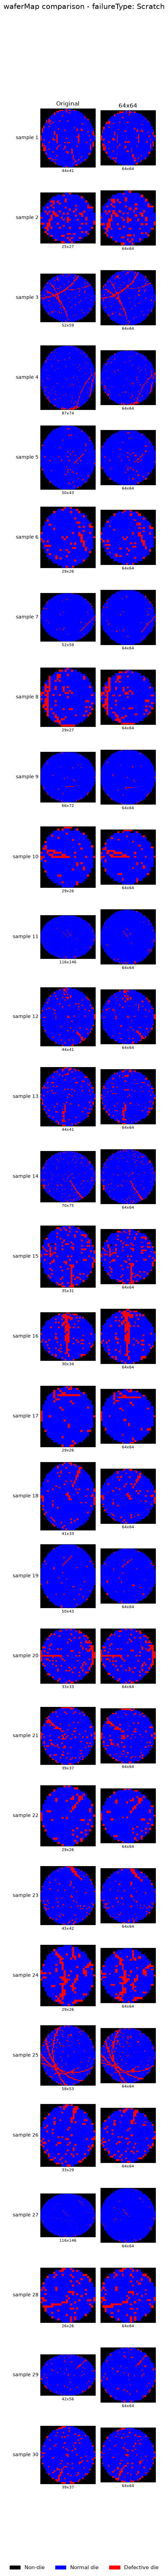

In [16]:
plot_resolution_comparison('Scratch')

In [17]:
"""
1) failureType이 'empty'인 데이터 제외
2) lot-group(lotName) 기준으로 train:val:test = 7:2:1 분할
   - StratifiedGroupKFold(n_splits=10)를 한 번만 수행해 10개 fold를 얻은 뒤,
     fold를 1개(test) / 2개(val) / 7개(train)로 묶어서 사용
   - 동일 lotName은 항상 하나의 fold(=하나의 split)에만 속하고, 각 fold는
     failureType 분포가 전체 데이터와 최대한 비슷하도록 배정되므로
     fold를 몇 개 묶어 합치더라도 그 조합의 분포는 전체 분포에 근사한다
"""

filtered = data[failure_type_str != 'empty'].copy()
filtered['failureTypeStr'] = failure_type_str[filtered.index]

y_all = filtered['failureTypeStr'].to_numpy()
groups_all = filtered['lotName'].to_numpy()

sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
fold_positions = [test_idx for _, test_idx in sgkf.split(np.zeros(len(y_all)), y_all, groups_all)]

test_pos = fold_positions[0]
val_pos = np.concatenate(fold_positions[1:3])
train_pos = np.concatenate(fold_positions[3:])

split_indices = {
    'train': filtered.index[train_pos],
    'val': filtered.index[val_pos],
    'test': filtered.index[test_pos],
}

# 검증: 동일 lot이 여러 split에 걸치지 않는지 확인
lot_to_split = {}
for split_name, idx in split_indices.items():
    for lot in filtered.loc[idx, 'lotName'].unique():
        assert lot_to_split.setdefault(lot, split_name) == split_name, f'lot {lot} split across multiple sets'

print('=' * 55)
print('[Split summary]')
for split_name, idx in split_indices.items():
    ratio = len(idx) / len(filtered) * 100
    print(f'- {split_name}: {len(idx):,}개 ({ratio:.1f}%)')
print('=' * 55)
print('[failureType distribution per split]')
dist = pd.DataFrame({
    split_name: filtered.loc[idx, 'failureTypeStr'].value_counts(normalize=True)
    for split_name, idx in split_indices.items()
}).fillna(0).loc[failure_order]
print(dist.round(3))
print('=' * 55)

[Split summary]
- train: 121,078개 (70.0%)
- val: 34,590개 (20.0%)
- test: 17,282개 (10.0%)
[failureType distribution per split]
                train    val   test
failureTypeStr                     
none            0.852  0.852  0.852
Center          0.025  0.025  0.025
Donut           0.003  0.003  0.003
Edge-Loc        0.030  0.030  0.030
Edge-Ring       0.056  0.056  0.056
Loc             0.021  0.021  0.021
Near-full       0.001  0.001  0.001
Random          0.005  0.005  0.005
Scratch         0.007  0.007  0.007


In [18]:
"""
train/val/test split을 npy로 저장

- waferMap은 리사이즈/one-hot 변환 없이 원본 그대로 저장 (wafer마다 shape이 달라 dtype=object)
- 리사이즈(64x64) + 3채널 one-hot 변환은 저장 시점이 아니라 사용 시점(Dataset/embedding 추출 등)에 수행
- label_encoder_classes.npy: failureType 문자열 <-> 정수 인덱스 매핑용 (failure_order 순서 고정,
  train.py의 FAILURE_CLASSES 하드코딩 순서와 동일하게 유지)
"""
from sklearn.preprocessing import LabelEncoder

processed_dir = '/home/geonyoung_lee/fab_scope/data/processed'
os.makedirs(processed_dir, exist_ok=True)

for split_name, idx in split_indices.items():
    X = filtered.loc[idx, 'waferMap'].to_numpy()
    y = filtered.loc[idx, 'failureTypeStr'].to_numpy()
    np.save(os.path.join(processed_dir, f'X_{split_name}.npy'), X, allow_pickle=True)
    np.save(os.path.join(processed_dir, f'y_{split_name}.npy'), y, allow_pickle=True)
    print(f'- {split_name}: X.shape={X.shape} (dtype={X.dtype}), y.shape={y.shape}')

label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(failure_order)
np.save(os.path.join(processed_dir, 'label_encoder_classes.npy'), label_encoder.classes_, allow_pickle=True)
print(f'- label_encoder_classes: {list(label_encoder.classes_)}')

- train: X.shape=(121078,) (dtype=object), y.shape=(121078,)
- val: X.shape=(34590,) (dtype=object), y.shape=(34590,)
- test: X.shape=(17282,) (dtype=object), y.shape=(17282,)
- label_encoder_classes: [np.str_('none'), np.str_('Center'), np.str_('Donut'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch')]


In [19]:
"""
[노이즈 탐색 1단계] train set의 defect 데이터(failureType='none' 제외)를
사전학습된 EfficientNet-B0으로 임베딩(1280차원) 추출

- data/processed/X_train.npy, y_train.npy에는 원본 waferMap(리사이즈/one-hot 미적용)이 저장되어 있음
- 여기서 64x64 nearest neighbor 리사이즈 + 3채널 one-hot 변환을 수행한 뒤 임베딩 추출
- classifier를 Identity로 교체해 GlobalAveragePooling 직후의 1280차원 벡터를 그대로 얻음
- CUDA 설치가 잘못되면 조용히 CPU로 넘어가지 않고 즉시 에러를 내도록 확정 체크
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

assert torch.cuda.is_available(), 'CUDA를 사용할 수 없습니다 - 설치를 확인하세요'
device = torch.device('cuda')
print('device:', torch.cuda.get_device_name(0))

X_train_full = np.load('/home/geonyoung_lee/fab_scope/data/processed/X_train.npy', allow_pickle=True)
y_train_full = np.load('/home/geonyoung_lee/fab_scope/data/processed/y_train.npy', allow_pickle=True)

defect_mask = y_train_full != 'none'
X_defect_raw = X_train_full[defect_mask]
y_defect = y_train_full[defect_mask]
print(f'defect 샘플 수: {len(y_defect):,}개')


def resize_and_onehot(wafer_map: np.ndarray, size: tuple = (64, 64)) -> np.ndarray:
    resized = resize_nearest(wafer_map, size)     # (64,64), 값 {0,1,2} 보존
    return np.eye(3, dtype=np.float32)[resized]   # (64,64,3) one-hot


X_defect = np.stack([resize_and_onehot(wm) for wm in X_defect_raw])

weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)
model.classifier = nn.Identity()
model.eval().to(device)

imagenet_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)


def extract_embeddings(images: np.ndarray, batch_size: int = 256) -> np.ndarray:
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            batch = images[start:start + batch_size]
            tensor = torch.from_numpy(batch).float().permute(0, 3, 1, 2).to(device)  # (B,3,64,64)
            tensor = (tensor - imagenet_mean) / imagenet_std
            emb = model(tensor)
            embeddings.append(emb.cpu().numpy())
    return np.concatenate(embeddings, axis=0)


embeddings = extract_embeddings(X_defect)
print(f'embeddings shape: {embeddings.shape}')

device: NVIDIA GeForce RTX 2060
defect 샘플 수: 17,861개
embeddings shape: (17861, 1280)


PCA 누적 설명 분산 비율: 0.909


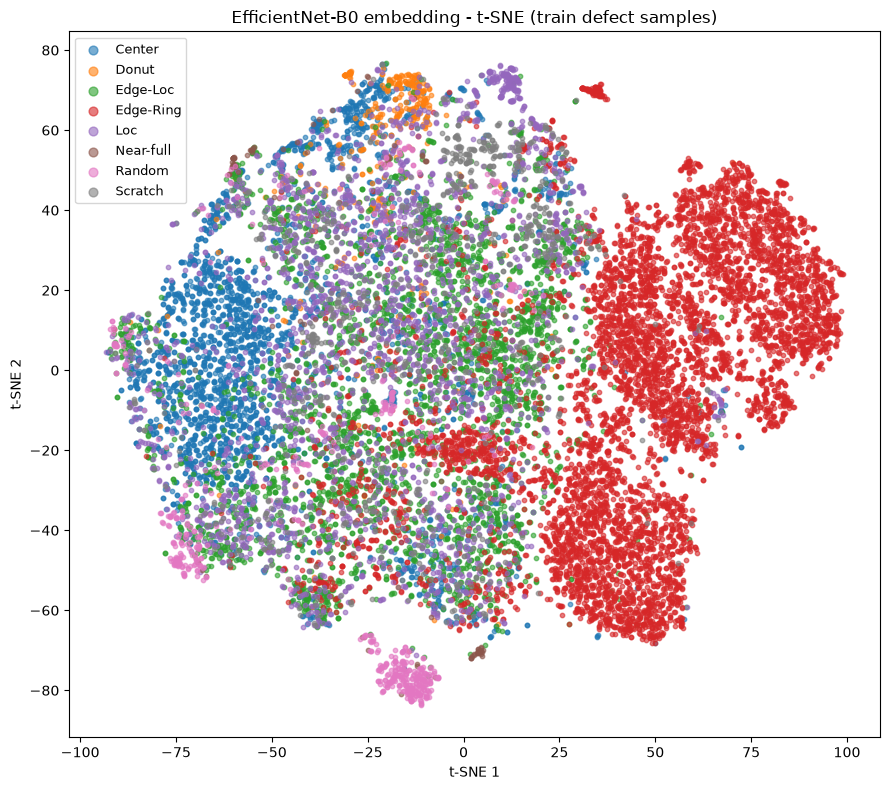

In [20]:
"""
[노이즈 탐색 2단계] 1280차원 임베딩 -> PCA로 50차원 압축 -> t-SNE로 2차원 축소 후 시각화
(t-SNE를 1280차원에 바로 적용하면 느리고 불안정하므로 PCA로 먼저 차원을 줄이는 것이 표준적인 방법)
"""
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)
print(f'PCA 누적 설명 분산 비율: {pca.explained_variance_ratio_.sum():.3f}')

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
embeddings_2d = tsne.fit_transform(embeddings_pca)

defect_order = [f for f in failure_order if f != 'none']
color_map = dict(zip(defect_order, plt.cm.tab10.colors))

plt.figure(figsize=(9, 8))
for ftype in defect_order:
    mask = y_defect == ftype
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                s=10, alpha=0.6, color=color_map[ftype], label=ftype)
plt.legend(markerscale=2, fontsize=9)
plt.title('EfficientNet-B0 embedding - t-SNE (train defect samples)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

In [21]:
"""
[노이즈 탐색 3단계] 이상치 후보 자동 탐지

원본 1280차원 임베딩 공간(t-SNE 2D 좌표가 아님)에서 각 점의 k-최근접 이웃 레이블을 보고
자기 레이블과 이웃 다수 레이블이 다른 점을 노이즈 후보로 표시
(t-SNE 2D 좌표상의 거리는 클러스터 간 실제 유사도를 왜곡할 수 있어 원본 임베딩 공간에서 탐지)
"""
from sklearn.neighbors import NearestNeighbors
from collections import Counter

k = 10
nn_model = NearestNeighbors(n_neighbors=k + 1).fit(embeddings)
_, neighbor_idx = nn_model.kneighbors(embeddings)
neighbor_idx = neighbor_idx[:, 1:]  # 자기 자신 제외

outlier_candidates = []
for i in range(len(y_defect)):
    neighbor_labels = y_defect[neighbor_idx[i]]
    majority_label, majority_count = Counter(neighbor_labels).most_common(1)[0]
    if majority_label != y_defect[i] and majority_count >= k * 0.6:
        outlier_candidates.append((i, y_defect[i], majority_label, majority_count))

print(f'노이즈 후보 {len(outlier_candidates)}개 발견 (전체 {len(y_defect):,}개 중)')
for i, own_label, majority_label, majority_count in outlier_candidates[:20]:
    print(f'idx={i}: 자기 레이블={own_label} vs 이웃 다수={majority_label} ({majority_count}/{k})')

노이즈 후보 1773개 발견 (전체 17,861개 중)
idx=0: 자기 레이블=Edge-Ring vs 이웃 다수=Edge-Loc (7/10)
idx=20: 자기 레이블=Scratch vs 이웃 다수=Loc (6/10)
idx=25: 자기 레이블=Edge-Loc vs 이웃 다수=Edge-Ring (8/10)
idx=34: 자기 레이블=Edge-Ring vs 이웃 다수=Edge-Loc (6/10)
idx=37: 자기 레이블=Edge-Loc vs 이웃 다수=Center (6/10)
idx=216: 자기 레이블=Random vs 이웃 다수=Edge-Loc (6/10)
idx=228: 자기 레이블=Edge-Ring vs 이웃 다수=Edge-Loc (6/10)
idx=243: 자기 레이블=Scratch vs 이웃 다수=Edge-Ring (6/10)
idx=256: 자기 레이블=Edge-Loc vs 이웃 다수=Edge-Ring (6/10)
idx=272: 자기 레이블=Edge-Loc vs 이웃 다수=Edge-Ring (6/10)
idx=273: 자기 레이블=Loc vs 이웃 다수=Edge-Loc (7/10)
idx=274: 자기 레이블=Edge-Ring vs 이웃 다수=Edge-Loc (8/10)
idx=298: 자기 레이블=Edge-Ring vs 이웃 다수=Edge-Loc (6/10)
idx=303: 자기 레이블=Center vs 이웃 다수=Edge-Loc (8/10)
idx=308: 자기 레이블=Loc vs 이웃 다수=Center (7/10)
idx=318: 자기 레이블=Loc vs 이웃 다수=Center (9/10)
idx=321: 자기 레이블=Loc vs 이웃 다수=Center (9/10)
idx=334: 자기 레이블=Loc vs 이웃 다수=Center (7/10)
idx=336: 자기 레이블=Center vs 이웃 다수=Donut (6/10)
idx=393: 자기 레이블=Scratch vs 이웃 다수=Edge-Ring (10/10)


In [22]:
"""
[노이즈 탐색 4단계] 후보 wafer를 눈으로 확인하고 노이즈 여부 판단

show_wafer_map(local_idx)로 원본 wafer map + t-SNE 상 위치 + 이웃 라벨 분포를 확인한 뒤,
노이즈로 판단되면 noise_indices에 추가 (실제 데이터 제거/재저장은 이 단계에서 하지 않음)
"""


def onehot_to_categorical(onehot: np.ndarray) -> np.ndarray:
    return np.argmax(onehot, axis=-1)


def show_wafer_map(local_idx: int):
    wafer = onehot_to_categorical(X_defect[local_idx])
    own_label = y_defect[local_idx]
    neighbor_labels = y_defect[neighbor_idx[local_idx]]

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(wafer, cmap=cmap, norm=norm, interpolation='nearest')
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].set_title(f'idx={local_idx} label={own_label}')

    axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, alpha=0.15, color='gray')
    axes[1].scatter(embeddings_2d[local_idx, 0], embeddings_2d[local_idx, 1],
                     s=120, color='red', marker='x')
    axes[1].set_title(f'neighbor labels: {Counter(neighbor_labels).most_common()}')
    plt.tight_layout()
    plt.show()


# outlier_candidates의 idx를 show_wafer_map()으로 눈으로 확인한 뒤,
# 노이즈가 심하다고 판단되면 아래 리스트에 추가 (예: noise_indices.append(idx))
noise_indices = []